<a href="https://colab.research.google.com/github/kav0309/ad-creative-analysis/blob/main/inde_wild_vs_plum_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Indē Wild vs Plum — Ad Creative Analysis
**Competitive intelligence dashboard: format, creative age, offers, copy style**

Run each cell top to bottom. Charts auto-export as PNG files.

In [ ]:
# ─── CELL 1: Install & Import ───────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Create output folder
os.makedirs('charts', exist_ok=True)

# Brand colour palette
INDE   = '#C8956C'   # warm terracotta — Indē Wild
PLUM   = '#6B3FA0'   # plum purple
BG     = '#FAFAF8'
GRID   = '#EBEBEB'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': BG,
    'figure.facecolor': BG,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
})

print('✅ Setup complete')

✅ Setup complete


In [ ]:
# ─── CELL 2: Data Entry ─────────────────────────────────────────────────────
# Pulled directly from your project_.xlsx

inde_data = pd.DataFrame({
    'ad': list(range(1, 13)),
    'format': [
        'Carousel', 'Video (UGC)', 'Carousel', 'Single image', 'Single image',
        'Carousel', 'Carousel', 'Carousel', 'Carousel', 'Carousel',
        'Single image', 'Carousel'
    ],
    'copy_style': [
        'Relatable/situational', 'Social proof', 'Relatable/situational',
        'Functional + urgency', 'Benefit-led', 'Ingredient-focused',
        'Offer-led', 'Lifestyle', 'Witty/Gen Z', 'Humour',
        'Brand philosophy', 'Seasonal'
    ],
    'offer': [
        'None', 'None', 'None', 'None', 'None', 'None',
        '20% off', 'None', 'None', 'None', 'None', 'None'
    ],
    'weeks_running': [6.5, 4.5, 6.5, 6, 6, 6, 0.5, 0.5, 2.5, 3, 3, 2.5],
    'brand': 'Indē Wild'
})

plum_data = pd.DataFrame({
    'ad': list(range(1, 13)),
    'format': [
        'Video (UGC)', 'Video (UGC)', 'Video (branded)', 'Video',
        'Video (branded)', 'Video', 'Video', 'Video',
        'Video (branded)', 'Video', 'Video', 'Video'
    ],
    'copy_style': [
        'Science/ingredient', 'Science/ingredient', 'Ingredient/benefit',
        'Problem-solution', 'Testimonial', 'Trial/low-risk offer',
        'Free gift offer', 'Payday urgency', 'Lifestyle/aspirational',
        'Myth-busting', 'Brand/product range', 'Ingredient science'
    ],
    'offer': [
        'None', 'None', 'None', '10% off', 'None',
        '₹599 trial kit', 'Free welcome kit', 'Free gifts on bundle',
        'None', 'None', 'None', 'None'
    ],
    'weeks_running': [7, 8, 3, 2.5, 6, 2.5, 2.5, 0.3, 1.5, 0.7, 0.3, 8],
    'brand': 'Plum'
})

df = pd.concat([inde_data, plum_data], ignore_index=True)
print(f'✅ Data loaded — {len(df)} ads total ({len(inde_data)} Indē Wild, {len(plum_data)} Plum)')

✅ Data loaded — 24 ads total (12 Indē Wild, 12 Plum)


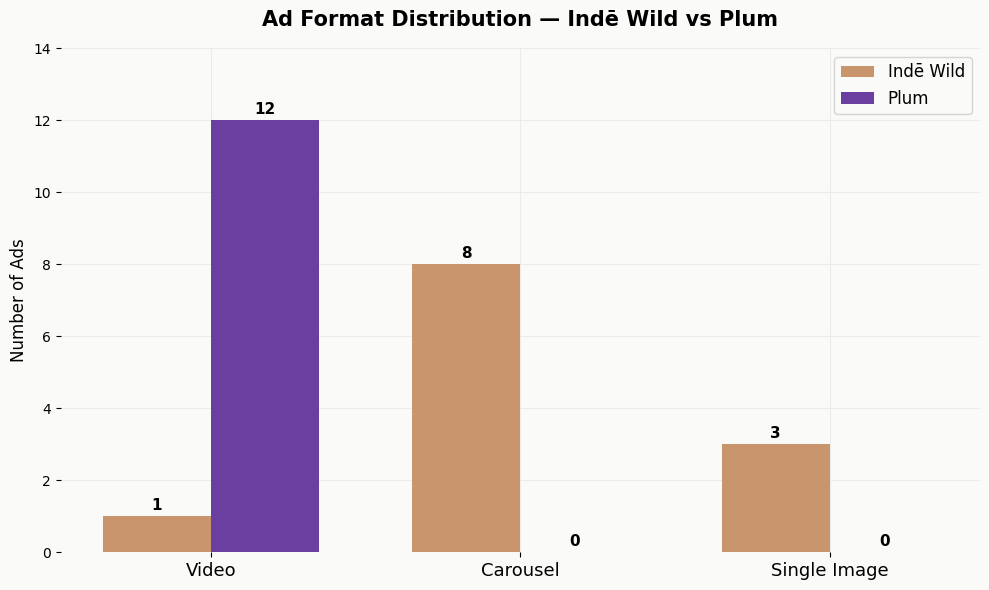

💾 Saved → charts/01_ad_format_comparison.png


In [ ]:
# ─── CELL 3: Chart 1 — Ad Format Comparison ─────────────────────────────────

def simplify_format(f):
    if 'Video' in f: return 'Video'
    if 'Carousel' in f: return 'Carousel'
    return 'Single Image'

df['format_simple'] = df['format'].apply(simplify_format)

all_formats = ['Video', 'Carousel', 'Single Image']
inde_counts = df[df.brand == 'Indē Wild']['format_simple'].value_counts().reindex(all_formats, fill_value=0)
plum_counts  = df[df.brand == 'Plum']['format_simple'].value_counts().reindex(all_formats, fill_value=0)

x = np.arange(len(all_formats))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, inde_counts.values, w, color=INDE, label='Indē Wild', zorder=3)
bars2 = ax.bar(x + w/2, plum_counts.values,  w, color=PLUM, label='Plum',     zorder=3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(all_formats, fontsize=13)
ax.set_ylabel('Number of Ads', fontsize=12)
ax.set_title('Ad Format Distribution — Indē Wild vs Plum', fontsize=15, fontweight='bold', pad=16)
ax.legend(fontsize=12)
ax.set_ylim(0, max(inde_counts.max(), plum_counts.max()) + 2)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('charts/01_ad_format_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('💾 Saved → charts/01_ad_format_comparison.png')

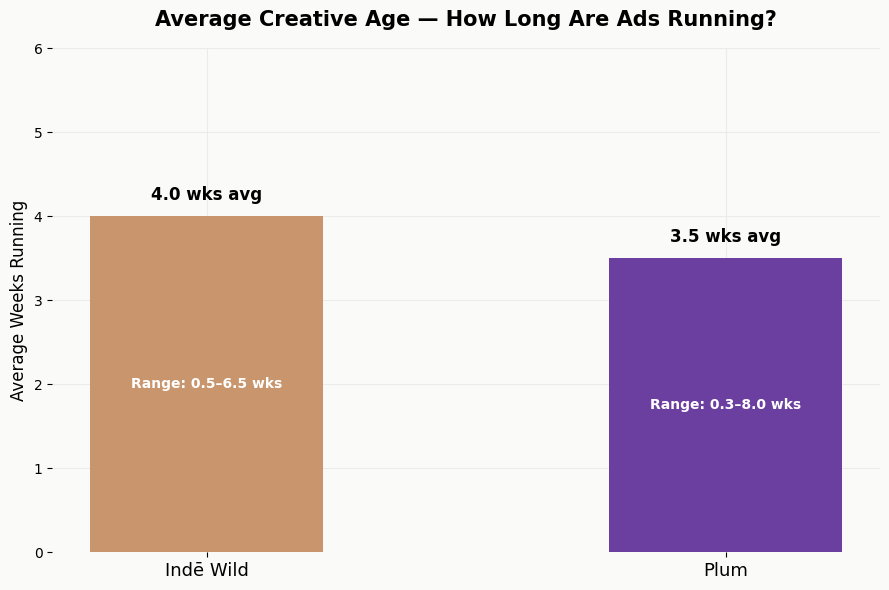

💾 Saved → charts/02_creative_age.png


In [ ]:
# ─── CELL 4: Chart 2 — Average Creative Age ─────────────────────────────────

avg_age = df.groupby('brand')['weeks_running'].agg(['mean', 'max', 'min']).round(1)

fig, ax = plt.subplots(figsize=(9, 6))

brands = ['Indē Wild', 'Plum']
colors = [INDE, PLUM]
means  = [avg_age.loc[b, 'mean'] for b in brands]
maxes  = [avg_age.loc[b, 'max']  for b in brands]
mins   = [avg_age.loc[b, 'min']  for b in brands]

bars = ax.bar(brands, means, color=colors, width=0.45, zorder=3)

for i, bar in enumerate(bars):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
            f'{h} wks avg', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.text(bar.get_x() + bar.get_width()/2, h/2,
            f'Range: {mins[i]}–{maxes[i]} wks',
            ha='center', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_ylabel('Average Weeks Running', fontsize=12)
ax.set_title('Average Creative Age — How Long Are Ads Running?', fontsize=15, fontweight='bold', pad=16)
ax.set_ylim(0, max(means) + 2)
ax.tick_params(axis='x', labelsize=13)

plt.tight_layout()
plt.savefig('charts/02_creative_age.png', dpi=180, bbox_inches='tight')
plt.show()
print('💾 Saved → charts/02_creative_age.png')

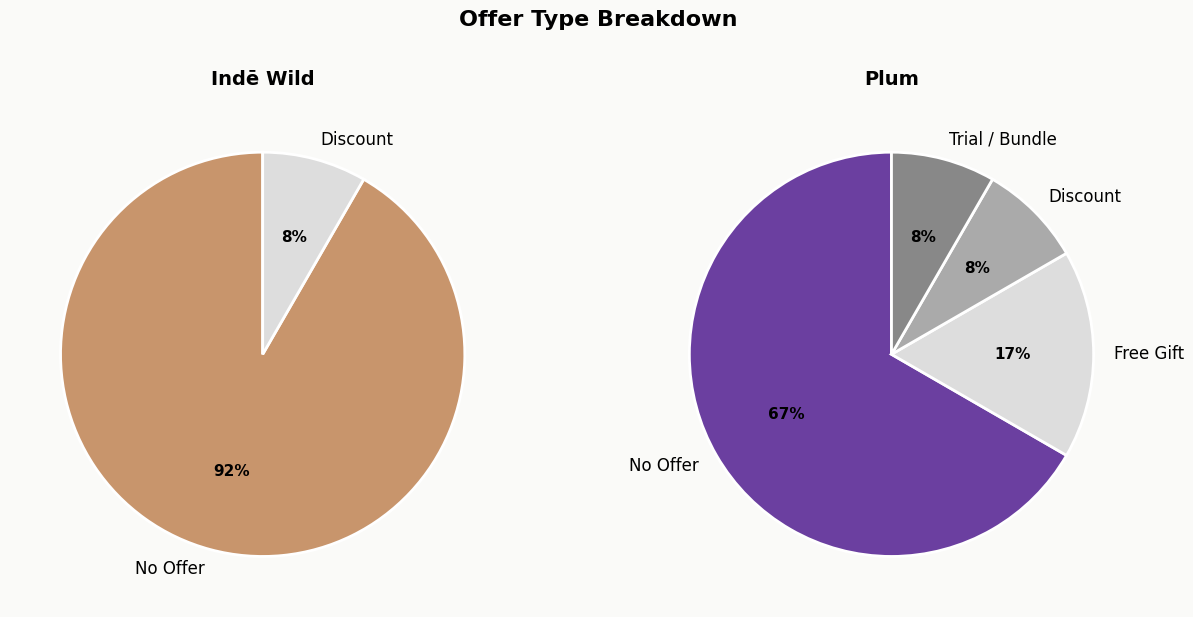

💾 Saved → charts/03_offer_breakdown.png


In [ ]:
# ─── CELL 5: Chart 3 — Offer Type Breakdown ─────────────────────────────────

def offer_bucket(o):
    if o == 'None': return 'No Offer'
    if 'off' in o.lower() or '%' in o: return 'Discount'
    if 'free' in o.lower(): return 'Free Gift'
    return 'Trial / Bundle'

df['offer_type'] = df['offer'].apply(offer_bucket)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, brand, color in zip(axes, ['Indē Wild', 'Plum'], [INDE, PLUM]):
    sub = df[df.brand == brand]['offer_type'].value_counts()
    wedges, texts, autotexts = ax.pie(
        sub.values,
        labels=sub.index,
        autopct='%1.0f%%',
        colors=[color, '#DDDDDD', '#AAAAAA', '#888888'][:len(sub)],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for t in texts: t.set_fontsize(12)
    for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold')
    ax.set_title(brand, fontsize=14, fontweight='bold', pad=12)

fig.suptitle('Offer Type Breakdown', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/03_offer_breakdown.png', dpi=180, bbox_inches='tight')
plt.show()
print('💾 Saved → charts/03_offer_breakdown.png')

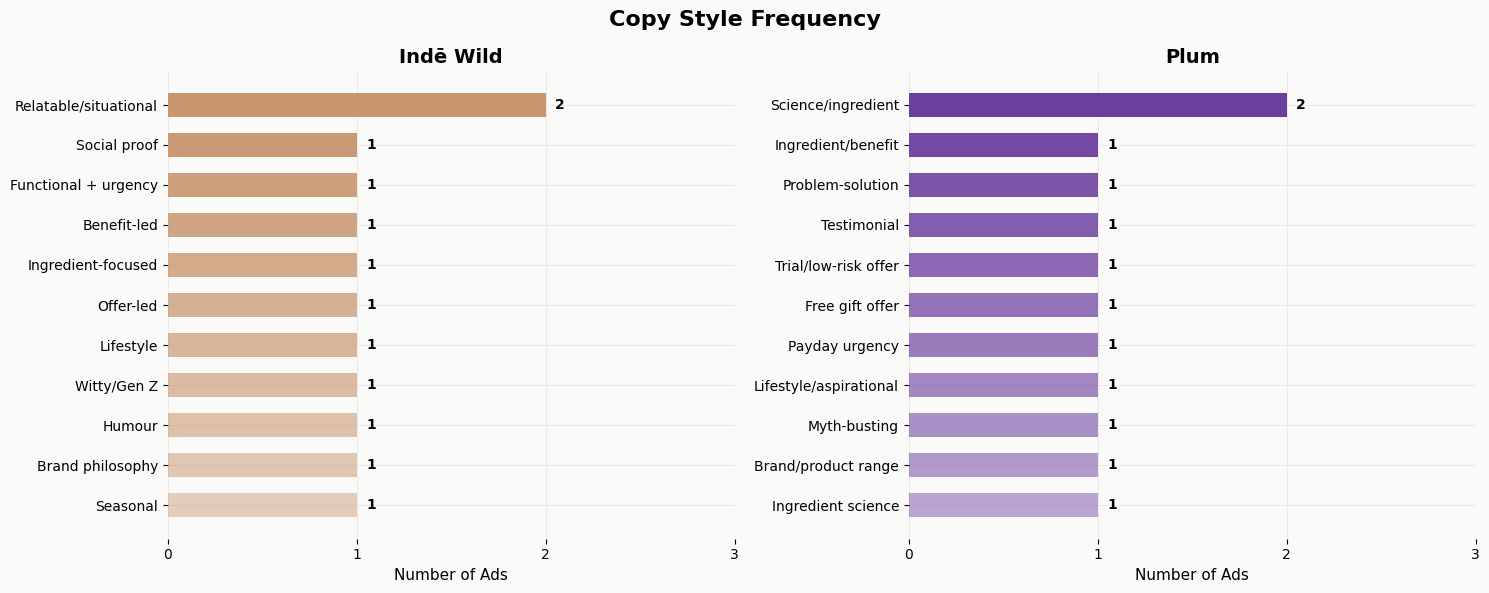

💾 Saved → charts/04_copy_style_frequency.png


In [ ]:
# ─── CELL 6: Chart 4 — Copy Style Frequency ─────────────────────────────────

inde_copy = df[df.brand == 'Indē Wild']['copy_style'].value_counts()
plum_copy  = df[df.brand == 'Plum']['copy_style'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, copy_counts, brand, color in zip(
        axes,
        [inde_copy, plum_copy],
        ['Indē Wild', 'Plum'],
        [INDE, PLUM]):

    # Gradient of alpha so most-used stands out
    alphas = np.linspace(1.0, 0.45, len(copy_counts))
    bar_colors = [(*plt.matplotlib.colors.to_rgb(color), a) for a in alphas]

    bars = ax.barh(copy_counts.index[::-1], copy_counts.values[::-1],
                   color=bar_colors[::-1], zorder=3, height=0.6)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
                str(int(w)), va='center', fontsize=10, fontweight='bold')

    ax.set_xlim(0, copy_counts.max() + 1)
    ax.set_xlabel('Number of Ads', fontsize=11)
    ax.set_title(brand, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

fig.suptitle('Copy Style Frequency', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_copy_style_frequency.png', dpi=180, bbox_inches='tight')
plt.show()
print('💾 Saved → charts/04_copy_style_frequency.png')

In [ ]:
# ─── CELL 7: Bonus — Summary Table ──────────────────────────────────────────

print('=' * 55)
print('       COMPETITIVE SNAPSHOT — Indē Wild vs Plum')
print('=' * 55)

for brand in ['Indē Wild', 'Plum']:
    sub = df[df.brand == brand]
    top_format = sub['format_simple'].value_counts().idxmax()
    top_copy   = sub['copy_style'].value_counts().idxmax()
    pct_offer  = round((sub['offer'] != 'None').mean() * 100)
    avg_wks    = sub['weeks_running'].mean().round(1)
    print(f'\n  {brand}')
    print(f'  • Dominant format  : {top_format}')
    print(f'  • Top copy style   : {top_copy}')
    print(f'  • % ads with offer : {pct_offer}%')
    print(f'  • Avg creative age : {avg_wks} weeks')

print('\n' + '=' * 55)
print('\n✅ All 4 charts saved in the charts/ folder!')
print('   Download them: Files panel (left sidebar) → charts/')

       COMPETITIVE SNAPSHOT — Indē Wild vs Plum

  Indē Wild
  • Dominant format  : Carousel
  • Top copy style   : Relatable/situational
  • % ads with offer : 8%
  • Avg creative age : 4.0 weeks

  Plum
  • Dominant format  : Video
  • Top copy style   : Science/ingredient
  • % ads with offer : 33%
  • Avg creative age : 3.5 weeks


✅ All 4 charts saved in the charts/ folder!
   Download them: Files panel (left sidebar) → charts/
